# Diffusion Model Basics

This notebook introduces the core theory behind **diffusion models** and then implements a complete, but deliberately small, toy example in 2D. The example contains the full diffusion workflow: a forward noising process, a learned reverse denoiser, and generation by iterative sampling.

To keep the notebook lightweight and fully transparent, we do **not** use a large neural network. Instead, we fit a nonlinear regression model for the denoising function using radial basis features. The mathematical training objective is the same one used in modern denoising diffusion probabilistic models (DDPMs); only the function approximator is simplified.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(7)


## 1. The forward diffusion process

A diffusion model starts with data $\mathbf{x}_0$ and gradually destroys structure by adding small amounts of Gaussian noise:

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\left(\sqrt{\alpha_t}\,\mathbf{x}_{t-1}, (1-\alpha_t)\mathbf{I}\right), \qquad \alpha_t = 1 - \beta_t.
$$

After many steps, the distribution approaches a simple Gaussian. The useful fact is that we can sample directly from any timestep $t$ without simulating all earlier steps:

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon},
\qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}),
$$

where $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$. This closed-form expression is what makes training efficient.


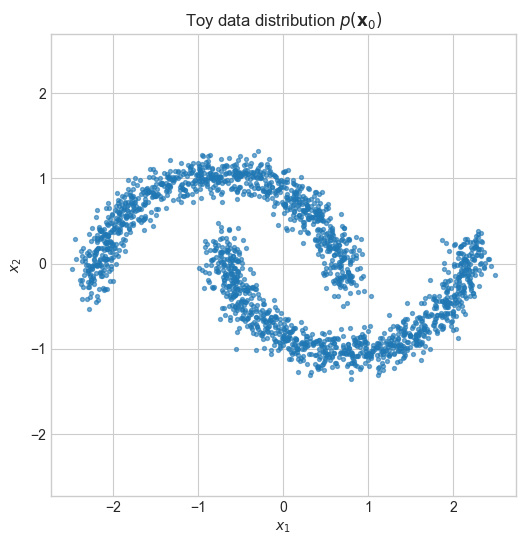

In [2]:
def make_toy_data(n_samples=2000):
    """Two curved 2D clusters: simple to visualize, non-Gaussian, and easy to sample."""
    n_half = n_samples // 2
    theta1 = np.random.uniform(0.1, np.pi - 0.1, n_half)
    theta2 = np.random.uniform(0.1, np.pi - 0.1, n_half)

    arc1 = np.stack([np.cos(theta1), np.sin(theta1)], axis=1)
    arc2 = np.stack([1 - np.cos(theta2), 1 - np.sin(theta2) - 0.4], axis=1)

    arc1 += 0.08 * np.random.randn(*arc1.shape)
    arc2 += 0.08 * np.random.randn(*arc2.shape)

    X = np.vstack([arc1, arc2]).astype(np.float64)
    X[:, 0] = 1.5 * X[:, 0] - 0.75
    X[:, 1] = 1.5 * X[:, 1] - 0.45
    return X

X = make_toy_data(2000)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.6, color='tab:blue')
ax.set_title('Toy data distribution $p(\mathbf{x}_0)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.axis('equal')
plt.show()


## 2. Visualizing the corruption process

The forward process should slowly erase the geometric structure in the data. At early times we still recognize the original shape; at late times the samples look almost Gaussian.


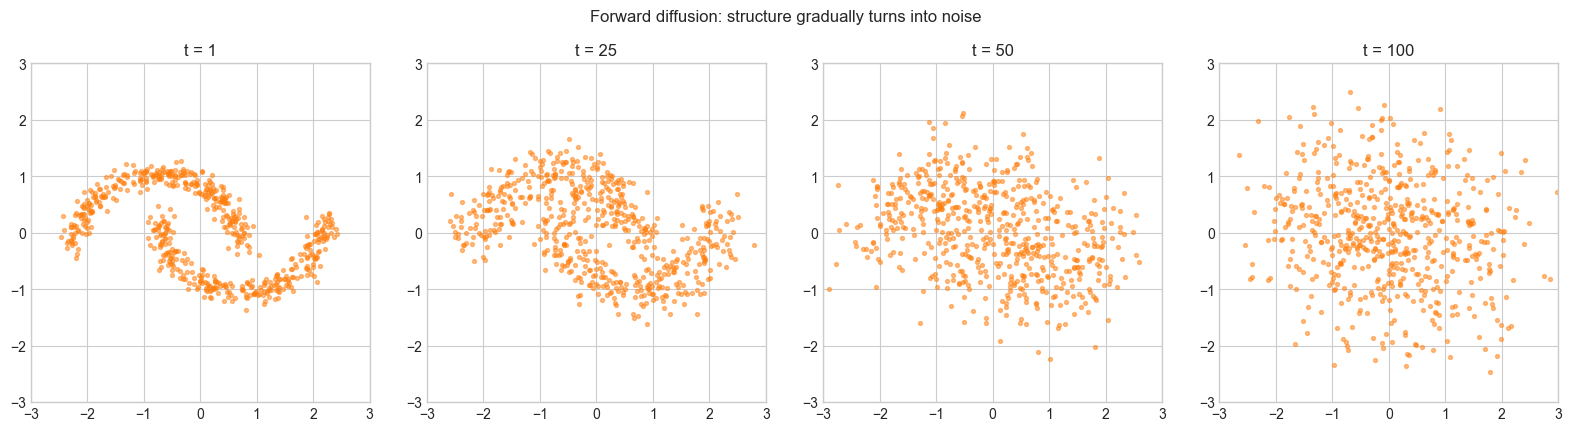

In [3]:
T = 100
betas = np.linspace(1e-4, 2e-2, T)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = np.random.randn(*x0.shape)
    alpha_bar_t = alpha_bars[t][:, None]
    return np.sqrt(alpha_bar_t) * x0 + np.sqrt(1 - alpha_bar_t) * noise

timesteps_to_plot = [0, 24, 49, 99]
idx = np.random.choice(len(X), size=600, replace=False)
x0_vis = X[idx]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t_plot in zip(axes, timesteps_to_plot):
    t_batch = np.full(len(x0_vis), t_plot, dtype=int)
    xt = q_sample(x0_vis, t_batch)
    ax.scatter(xt[:, 0], xt[:, 1], s=8, alpha=0.5, color='tab:orange')
    ax.set_title(f't = {t_plot + 1}')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')

plt.suptitle('Forward diffusion: structure gradually turns into noise', y=1.02)
plt.tight_layout()
plt.show()


## 3. What the model learns

During generation we only observe $\mathbf{x}_t$, not the clean sample $\mathbf{x}_0$. So the reverse conditional is not directly available. DDPMs solve this by learning a model that predicts the noise used in the forward process:

$$
\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \approx \boldsymbol{\epsilon}.
$$

The standard objective is

$$
\mathcal{L}(\theta) = \mathbb{E}_{\mathbf{x}_0, t, \boldsymbol{\epsilon}}\left[\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2\right].
$$

In large diffusion models, $\epsilon_\theta$ is a deep neural network. Here we keep the same objective but use a simpler nonlinear regressor built from **radial basis functions (RBFs)**. That keeps the implementation small while still learning a useful denoiser.


In [4]:
def build_training_pairs(x0, n_pairs=16000):
    idx = np.random.randint(0, len(x0), size=n_pairs)
    x0_batch = x0[idx]
    t = np.random.randint(0, T, size=n_pairs)
    noise = np.random.randn(*x0_batch.shape)
    xt = q_sample(x0_batch, t, noise)
    tau = t[:, None] / (T - 1)
    return xt, tau, noise, t


def pairwise_squared_distances(A, B):
    A2 = np.sum(A**2, axis=1, keepdims=True)
    B2 = np.sum(B**2, axis=1, keepdims=True).T
    return np.maximum(A2 + B2 - 2 * A @ B.T, 0.0)


class RBFDenoiser:
    def __init__(self, n_centers=96, ridge=1e-4):
        self.n_centers = n_centers
        self.ridge = ridge
        self.centers = None
        self.gamma = None
        self.W = None

    def _design_matrix(self, xt, tau):
        Z = np.hstack([xt, tau])
        D2 = pairwise_squared_distances(Z, self.centers)
        Phi_rbf = np.exp(-self.gamma * D2)
        Phi_poly = np.column_stack([
            xt[:, 0], xt[:, 1], tau[:, 0],
            xt[:, 0] * xt[:, 1], xt[:, 0] * tau[:, 0], xt[:, 1] * tau[:, 0],
            xt[:, 0] ** 2, xt[:, 1] ** 2,
            np.sin(np.pi * tau[:, 0]), np.cos(np.pi * tau[:, 0]),
            np.ones(len(xt))
        ])
        return np.hstack([Phi_rbf, Phi_poly])

    def fit(self, xt, tau, noise):
        Z = np.hstack([xt, tau])
        center_idx = np.random.choice(len(Z), size=self.n_centers, replace=False)
        self.centers = Z[center_idx]

        subset = Z[np.random.choice(len(Z), size=min(1200, len(Z)), replace=False)]
        D2_subset = pairwise_squared_distances(subset, self.centers)
        median_d2 = np.median(D2_subset[D2_subset > 0])
        self.gamma = 1.0 / max(median_d2, 1e-6)

        Phi = self._design_matrix(xt, tau)
        reg = self.ridge * np.eye(Phi.shape[1])
        self.W = np.linalg.solve(Phi.T @ Phi + reg, Phi.T @ noise)
        return self

    def predict(self, xt, t):
        t = np.asarray(t)
        if t.ndim == 0:
            t = np.full(len(xt), int(t))
        tau = t[:, None] / (T - 1)
        Phi = self._design_matrix(xt, tau)
        return Phi @ self.W


xt_train, tau_train, noise_train, t_train = build_training_pairs(X, n_pairs=16000)
model = RBFDenoiser(n_centers=96, ridge=1e-4).fit(xt_train, tau_train, noise_train)
pred_train = model.predict(xt_train, t_train)
train_mse = np.mean((pred_train - noise_train) ** 2)
train_mse


np.float64(0.6115474362138829)

## 4. Training result

Because the forward process generates unlimited supervised pairs $(\mathbf{x}_t, t, \boldsymbol{\epsilon})$, fitting the denoiser is straightforward. Here we train on a synthetic set of noisy examples and report the mean-squared error on that set.

This is conceptually the same as training a neural diffusion model: sample a clean point, sample a timestep, inject known noise, and fit the model to recover that noise.


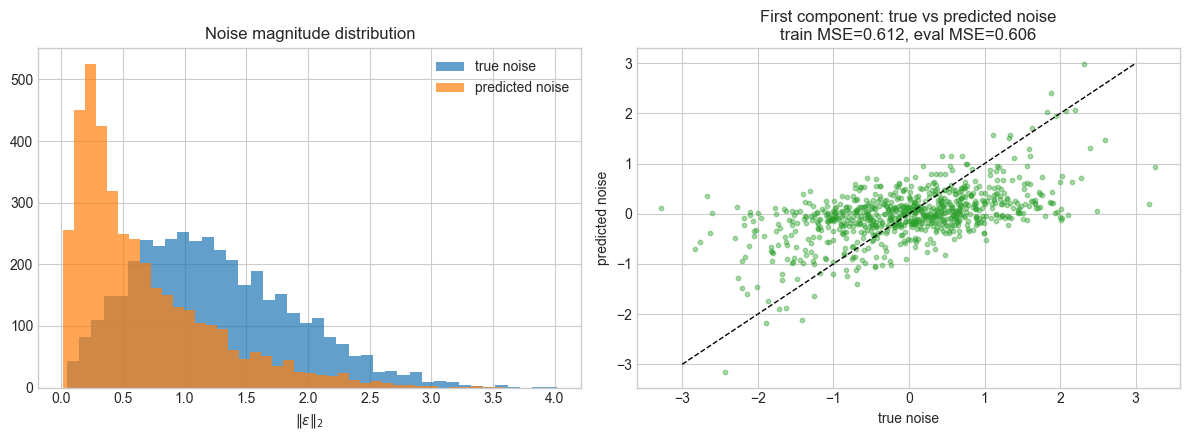

In [5]:
xt_eval, tau_eval, noise_eval, t_eval = build_training_pairs(X, n_pairs=4000)
pred_eval = model.predict(xt_eval, t_eval)
eval_mse = np.mean((pred_eval - noise_eval) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(np.linalg.norm(noise_eval, axis=1), bins=40, alpha=0.7, label='true noise', color='tab:blue')
axes[0].hist(np.linalg.norm(pred_eval, axis=1), bins=40, alpha=0.7, label='predicted noise', color='tab:orange')
axes[0].set_title('Noise magnitude distribution')
axes[0].set_xlabel('$\|\epsilon\|_2$')
axes[0].legend()

axes[1].scatter(noise_eval[:800, 0], pred_eval[:800, 0], s=10, alpha=0.4, color='tab:green')
axes[1].plot([-3, 3], [-3, 3], 'k--', lw=1)
axes[1].set_title(f'First component: true vs predicted noise\ntrain MSE={train_mse:.3f}, eval MSE={eval_mse:.3f}')
axes[1].set_xlabel('true noise')
axes[1].set_ylabel('predicted noise')

plt.tight_layout()
plt.show()


## 5. Visualizing denoising directions

For a fixed timestep, the learned noise predictor defines a local direction for moving corrupted points back toward the data manifold. Looking at this vector field is a useful sanity check: good denoisers point inward toward likely data regions instead of wandering randomly.


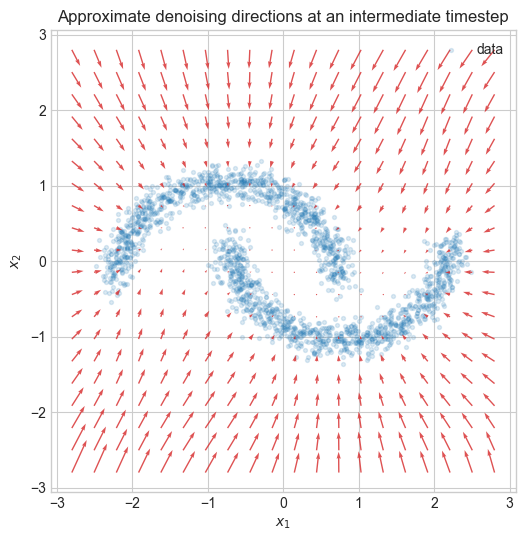

In [6]:
grid_x, grid_y = np.meshgrid(np.linspace(-2.8, 2.8, 20), np.linspace(-2.8, 2.8, 20))
grid = np.stack([grid_x.ravel(), grid_y.ravel()], axis=1)
t_vis = np.full(len(grid), 60, dtype=int)
pred = model.predict(grid, t_vis)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.15, color='tab:blue', label='data')
ax.quiver(grid[:, 0], grid[:, 1], -pred[:, 0], -pred[:, 1], color='tab:red', alpha=0.8)
ax.set_title('Approximate denoising directions at an intermediate timestep')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axis('equal')
ax.legend()
plt.show()


## 6. Reverse diffusion and generation

To generate new samples, we start from Gaussian noise $\mathbf{x}_T \sim \mathcal{N}(0, I)$ and step backward. A DDPM-style reverse update is

$$
\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right) + \sigma_t \mathbf{z},
$$

with $\mathbf{z} \sim \mathcal{N}(0, I)$ for $t > 1$. The learned denoiser removes a little noise at every step, and the sample gradually takes shape.


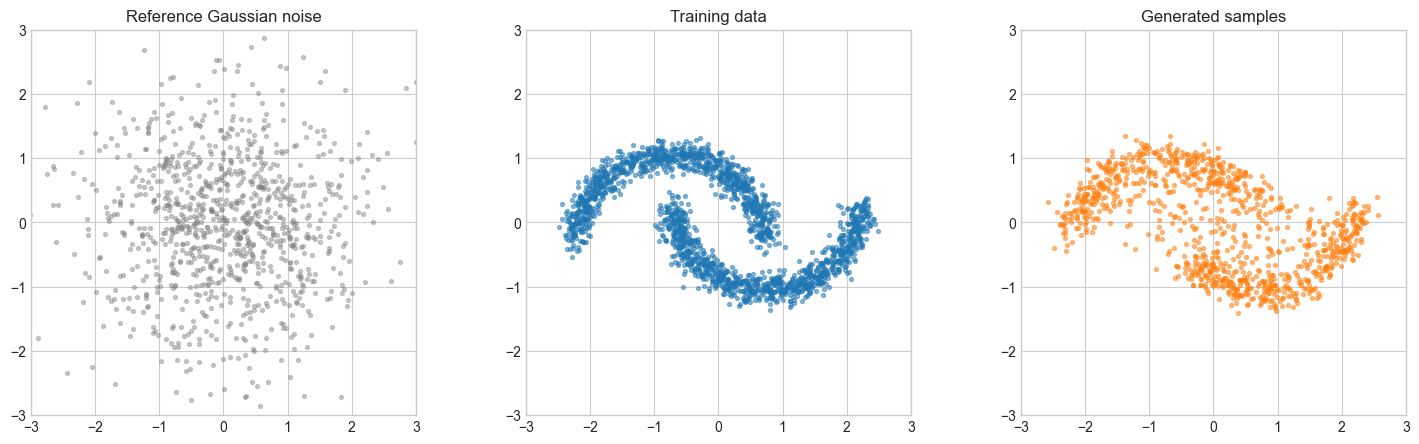

In [7]:
def sample_reverse_process(model, n_samples=1000, store_steps=(99, 74, 49, 24, 0)):
    x = np.random.randn(n_samples, 2)
    snapshots = {}

    for t in range(T - 1, -1, -1):
        eps_theta = model.predict(x, np.full(n_samples, t, dtype=int))

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        mean = (1 / np.sqrt(alpha_t)) * (
            x - (beta_t / np.sqrt(1 - alpha_bar_t)) * eps_theta
        )

        if t > 0:
            x = mean + np.sqrt(beta_t) * np.random.randn(*x.shape)
        else:
            x = mean

        if t in store_steps:
            snapshots[t] = x.copy()

    return x, snapshots


samples, snapshots = sample_reverse_process(model, n_samples=1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

reference_noise = np.random.randn(1000, 2)
axes[0].scatter(reference_noise[:, 0], reference_noise[:, 1], s=8, alpha=0.4, color='gray')
axes[0].set_title('Reference Gaussian noise')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_aspect('equal')

axes[1].scatter(X[:, 0], X[:, 1], s=8, alpha=0.5, color='tab:blue')
axes[1].set_title('Training data')
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].set_aspect('equal')

axes[2].scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.5, color='tab:orange')
axes[2].set_title('Generated samples')
axes[2].set_xlim(-3, 3)
axes[2].set_ylim(-3, 3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()


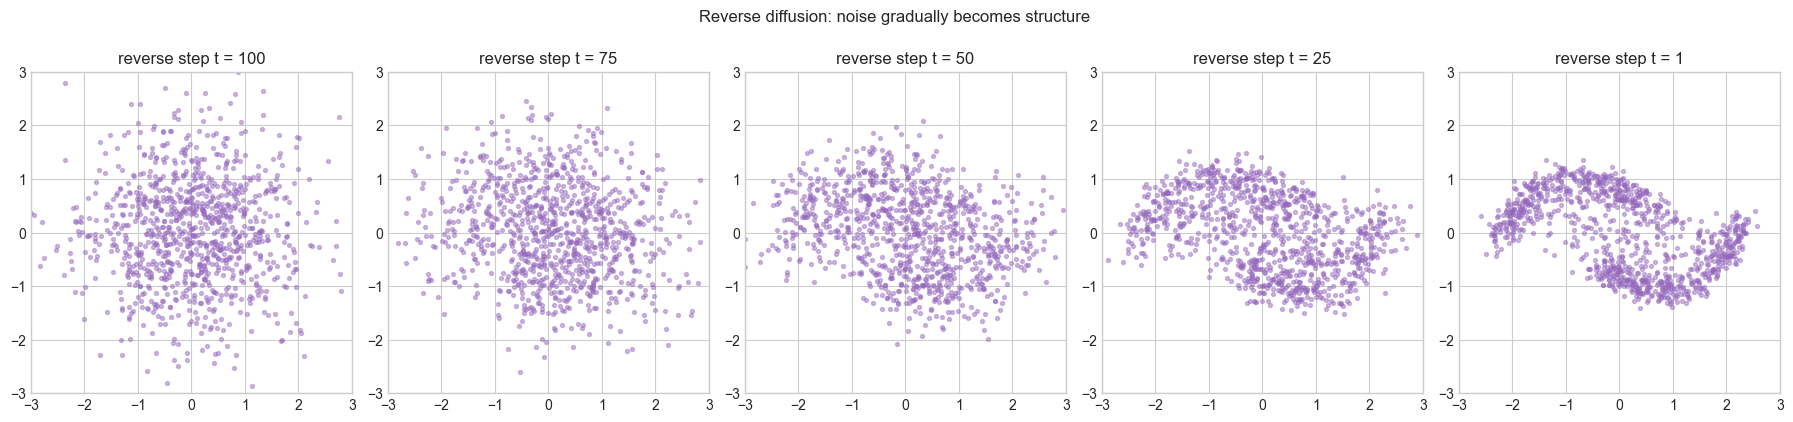

In [8]:
ordered_steps = [99, 74, 49, 24, 0]
fig, axes = plt.subplots(1, len(ordered_steps), figsize=(18, 4))

for ax, t_plot in zip(axes, ordered_steps):
    pts = snapshots[t_plot]
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.45, color='tab:purple')
    ax.set_title(f'reverse step t = {t_plot + 1}')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')

plt.suptitle('Reverse diffusion: noise gradually becomes structure', y=1.02)
plt.tight_layout()
plt.show()


## 7. What to take away

This toy notebook already contains the central diffusion-model idea:

- define a forward process that gradually destroys structure,
- fit a model that predicts the injected noise at arbitrary timesteps,
- use that denoiser to iteratively reverse the corruption process.

Modern diffusion models use richer architectures, better time embeddings, and more careful samplers, but the core logic is exactly the same.

In Earth science, the same perspective is useful for any task that requires generating plausible high-dimensional states under uncertainty: spatial downscaling, ensemble refinement, gap filling, and surrogate generative modeling of fields.
